<a href="https://colab.research.google.com/github/Shankari1548/My_projects/blob/main/Netflix_Dashboard.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
# Load dataset

import io
from google.colab import files

uploaded = files.upload()

for fn in uploaded.keys():
  print('User uploaded file "{name}" with length {length} bytes'.format(
      name=fn, length=len(uploaded[fn])))
  df = pd.read_csv(io.StringIO(uploaded[fn].decode('utf-8')))

Saving netflix_titles.csv to netflix_titles.csv
User uploaded file "netflix_titles.csv" with length 3399671 bytes


In [3]:
# Basic info

print(df.shape)
print(df.info())
df.head()

(8807, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB
None


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [ ]:
from google.colab import sheets
sheet = sheets.InteractiveSheet(df=df)

In [4]:
# Handle missing values

df.isnull().sum()

,0
show_id,0
type,0
title,0
director,2634
cast,825
country,831
date_added,10
release_year,0
rating,4
duration,3


In [5]:
# Fill missing categorical values with 'Unknown'

cols_to_fill = ['director', 'cast', 'country', 'date_added', 'rating']
df[cols_to_fill] = df[cols_to_fill].fillna('Unknown')

In [6]:
# Handle missing values

df.isnull().sum()

,0
show_id,0
type,0
title,0
director,0
cast,0
country,0
date_added,0
release_year,0
rating,0
duration,3


In [7]:
# Convert date_added to datetime

df.rename(columns={'date_added': 'date_time'}, inplace=True)

In [8]:
# Added a default date

df['date_time'] = df['date_time'].fillna(pd.Timestamp('1999-11-15'))

In [9]:
df.isnull().sum()

,0
show_id,0
type,0
title,0
director,0
cast,0
country,0
date_time,0
release_year,0
rating,0
duration,3


In [10]:
# Check and fill missing values safely


if 'duration' in df.columns:
    df['duration'] = df['duration'].fillna(df['duration'].mode()[0])

if 'year_added' in df.columns:
    df['year_added'] = df['year_added'].fillna(pd.Timestamp(2023))
else:
    # If 'year_added' doesn't exist, create it
    df['year_added'] = pd.Timestamp(2023)


In [11]:
# Remove duplicates

df.drop_duplicates(inplace=True)

In [12]:
# EDA

/tmp/ipykernel_702/1039190034.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='type', palette='Set2')


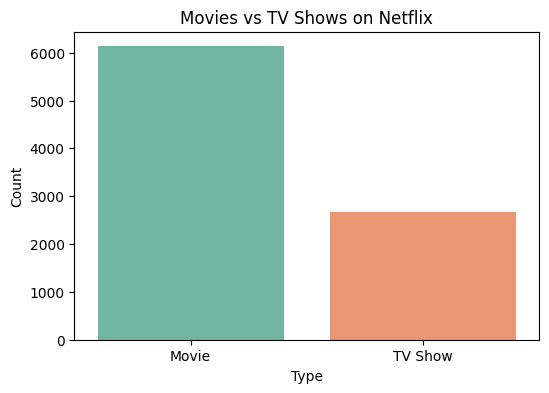

In [13]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='type', palette='Set2')
plt.title("Movies vs TV Shows on Netflix")
plt.xlabel("Type")
plt.ylabel("Count")
plt.show()


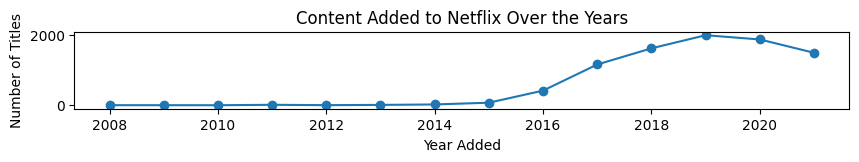

In [14]:
df['year_added'] = pd.to_datetime(df['date_time'],errors='coerce').dt.year
content_by_year = df['year_added'].value_counts().sort_index()

plt.figure(figsize=(10,1))
content_by_year.plot(kind='line', marker='o')
plt.title("Content Added to Netflix Over the Years")
plt.xlabel("Year Added")
plt.ylabel("Number of Titles")
plt.show()


/tmp/ipykernel_702/3651630463.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_countries.values, y=top_countries.index, palette='coolwarm')


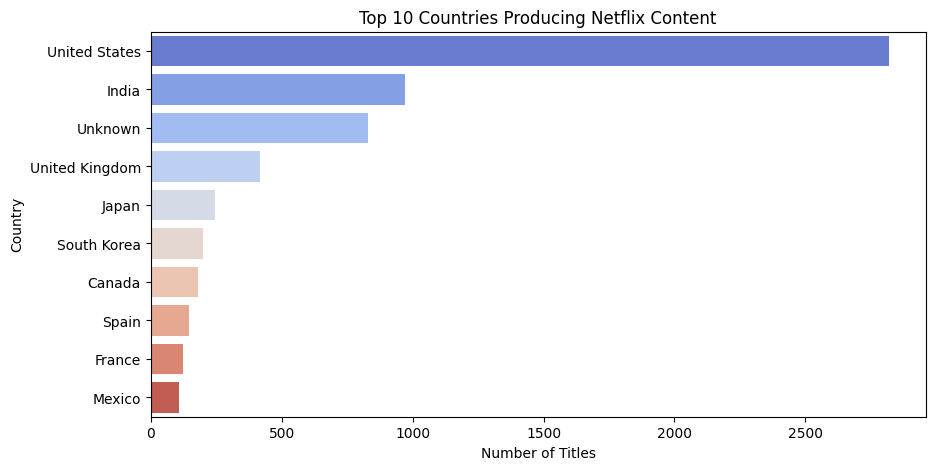

In [15]:
top_countries = df['country'].value_counts().head(10)

plt.figure(figsize=(10,5))
sns.barplot(x=top_countries.values, y=top_countries.index, palette='coolwarm')
plt.title("Top 10 Countries Producing Netflix Content")
plt.xlabel("Number of Titles")
plt.ylabel("Country")
plt.show()


/tmp/ipykernel_702/2010387594.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='rating', order=df['rating'].value_counts().index, palette='viridis')


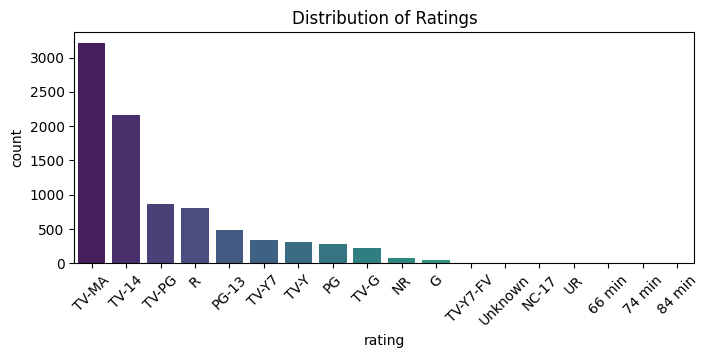

In [16]:
plt.figure(figsize=(8,3))
sns.countplot(data=df, x='rating', order=df['rating'].value_counts().index, palette='viridis')
plt.title("Distribution of Ratings")
plt.xticks(rotation=45)
plt.show()


/tmp/ipykernel_702/270185175.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=genres_df, x='Count', y='Genre', palette='magma')


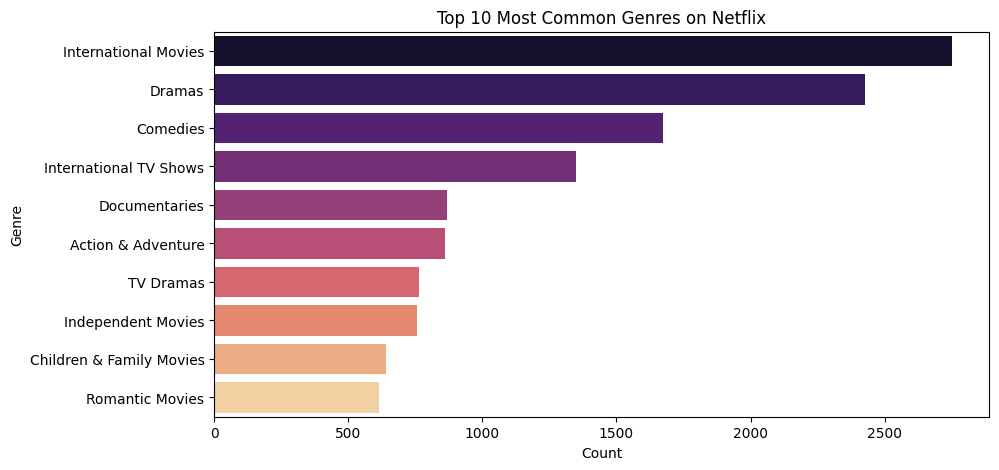

In [17]:
# Split genres and count frequency
from collections import Counter

genres = df['listed_in'].dropna().apply(lambda x: [i.strip() for i in x.split(',')])
genre_count = Counter([g for sublist in genres for g in sublist]).most_common(10)

genres_df = pd.DataFrame(genre_count, columns=['Genre', 'Count'])

plt.figure(figsize=(10,5))
sns.barplot(data=genres_df, x='Count', y='Genre', palette='magma')
plt.title("Top 10 Most Common Genres on Netflix")
plt.show()


/tmp/ipykernel_702/1829666532.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_directors.values, y=top_directors.index, palette='crest')


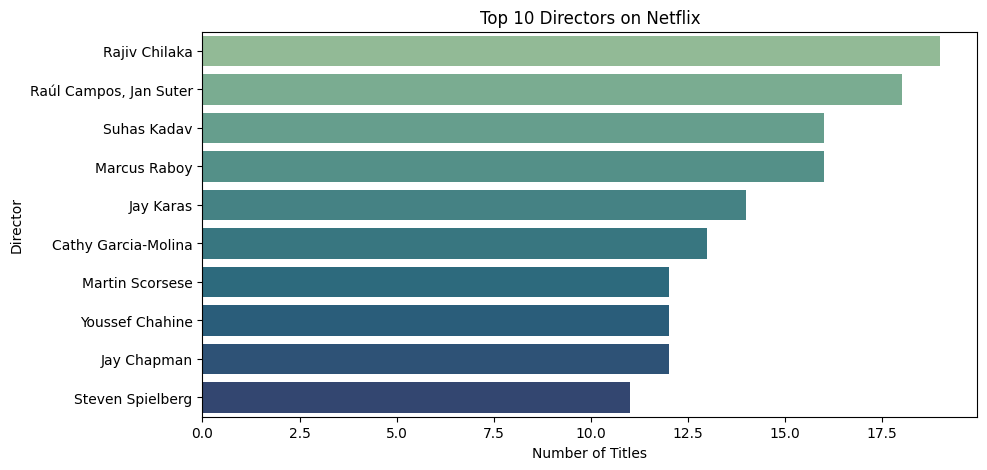

In [18]:
top_directors = df[df['director'] != 'Unknown']['director'].value_counts().head(10)

plt.figure(figsize=(10,5))
sns.barplot(x=top_directors.values, y=top_directors.index, palette='crest')
plt.title("Top 10 Directors on Netflix")
plt.xlabel("Number of Titles")
plt.ylabel("Director")
plt.show()


### Top 10 Actors

In [ ]:
top_actors = df[df['cast'] != 'Unknown']['cast'].apply(lambda x: x.split(',')).explode().str.strip().value_counts().head(10)

plt.figure(figsize=(10,5))
sns.barplot(x=top_actors.values, y=top_actors.index, palette='rocket')
plt.title("Top 10 Actors on Netflix")
plt.xlabel("Number of Titles")
plt.ylabel("Actor")
plt.show()

### Movie and TV Show Duration Analysis

In [ ]:
# Extract numerical duration for movies
movies_df = df[df['type'] == 'Movie'].copy()
movies_df['duration_numeric'] = movies_df['duration'].str.replace(' min', '').astype(float)

# Extract numerical duration for TV shows (number of seasons)
tv_shows_df = df[df['type'] == 'TV Show'].copy()
tv_shows_df['duration_numeric'] = tv_shows_df['duration'].str.replace(' Seasons', '').str.replace(' Season', '').astype(float)

# Plotting movie duration distribution
plt.figure(figsize=(12, 6))
sns.histplot(movies_df['duration_numeric'], bins=30, kde=True)
plt.title('Distribution of Movie Durations (minutes)')
plt.xlabel('Duration (minutes)')
plt.ylabel('Count')
plt.show()

# Plotting TV show season distribution
plt.figure(figsize=(8, 5))
sns.countplot(x=tv_shows_df['duration_numeric'], palette='viridis')
plt.title('Distribution of TV Show Seasons')
plt.xlabel('Number of Seasons')
plt.ylabel('Count')
plt.show()